Burn 1 Δv ideal             : 2.4321 km/s
Burn 1 Δv finite-corrected  : 2.5130 km/s
T/W ratio at ignition       : 0.1275  (ideal impulsive > 0.1)
LEO to GEO Chemical Propulsion Transfer – Basilisk
Initial Altitude   : 278.0 km
Final Altitude     : 35786.0 km
Thrust             : 1000 N
Specific Impulse   : 220.0 s
Initial Mass       : 800.0 kg
Initial Speed      : 7.7386 km/s
Target Speed (GEO) : 3.0747 km/s

Ideal Δv₁ (perigee kick) : 2.4321 km/s
Ideal Δv₂ (apogee  kick) : 1.4691 km/s
Ideal Δv total           : 3.9012 km/s
Corrected Δv₁ (finite)   : 2.5130 km/s

PHASE 1 – Perigee Kick Burn
Estimated Burn 1 duration   : 1188 s  (19.8 min)
Burn 1 complete at t = 1187.0 s
  Δv delivered   : 2.5136 km/s  (corrected target 2.5130 km/s)
  Speed achieved : 9.3802 km/s
  Radius         : 7645.41 km
  Mass remaining : 249.84 kg

PHASE 2 – Coast (transfer ellipse, perigee → apogee)
Apogee located at t_coast = 5.13 h
  Apogee radius   : 42031.34 km  (altitude 35653.34 km)
  Speed at apogee : 1.6

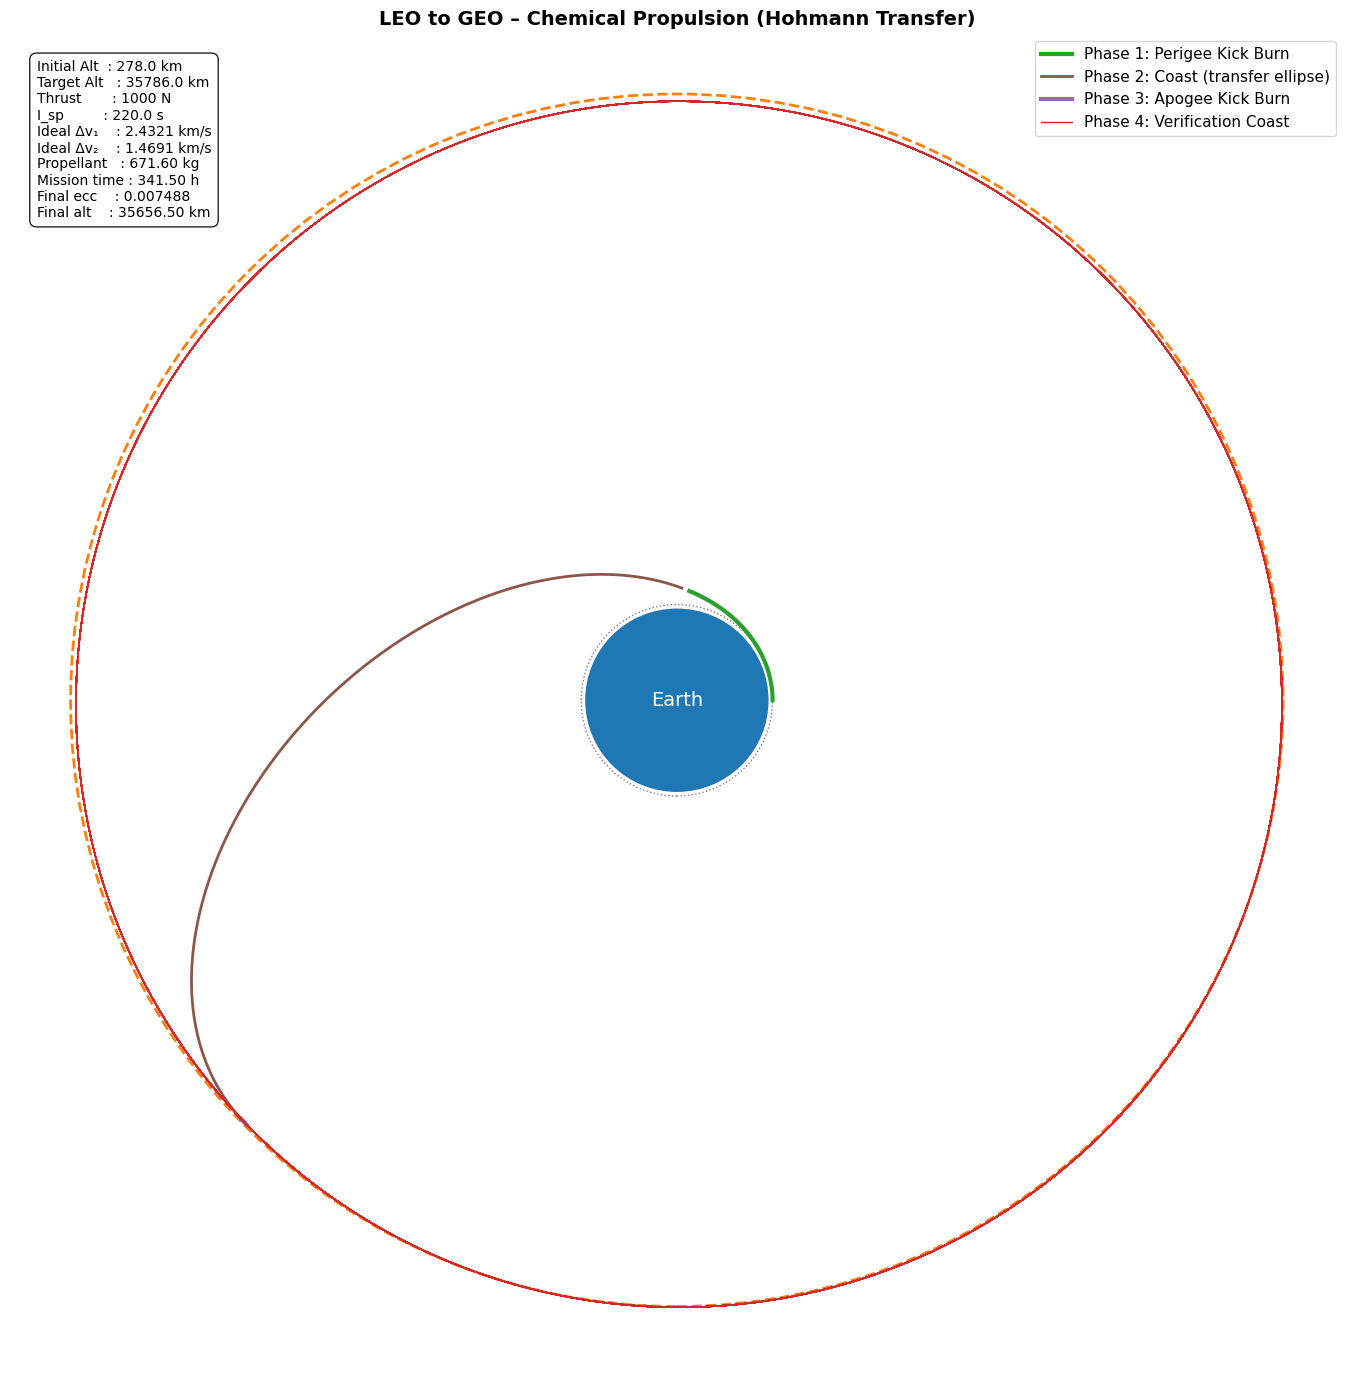

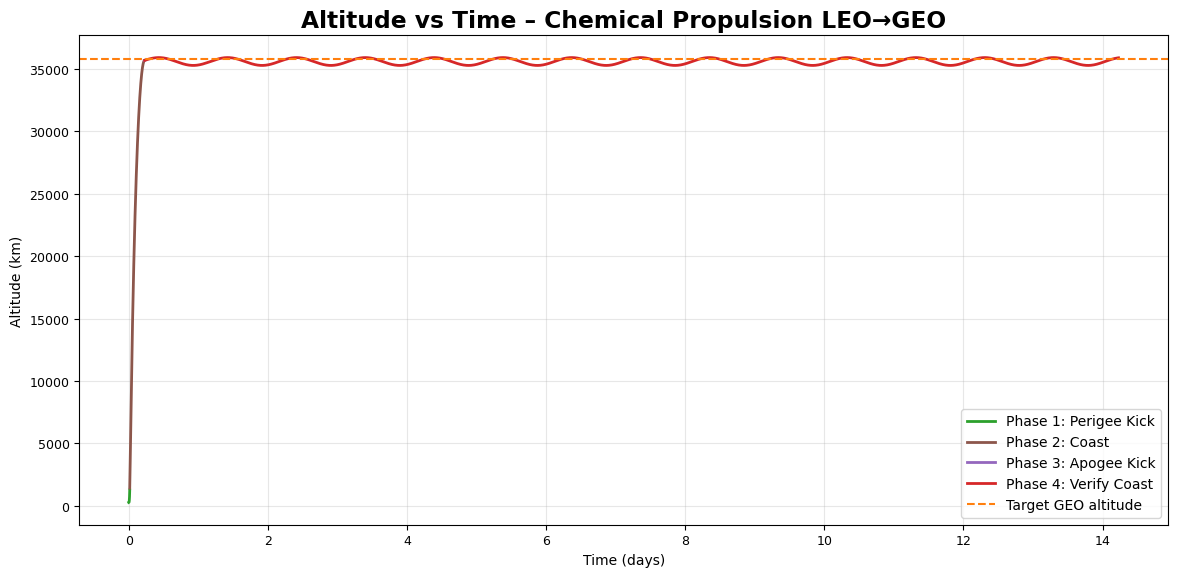

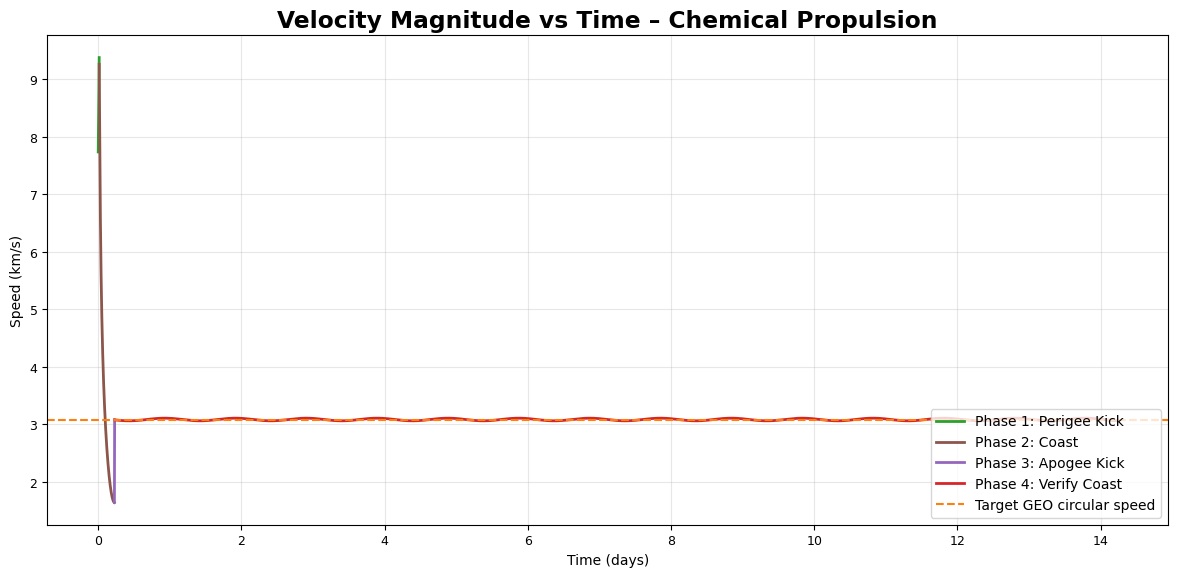

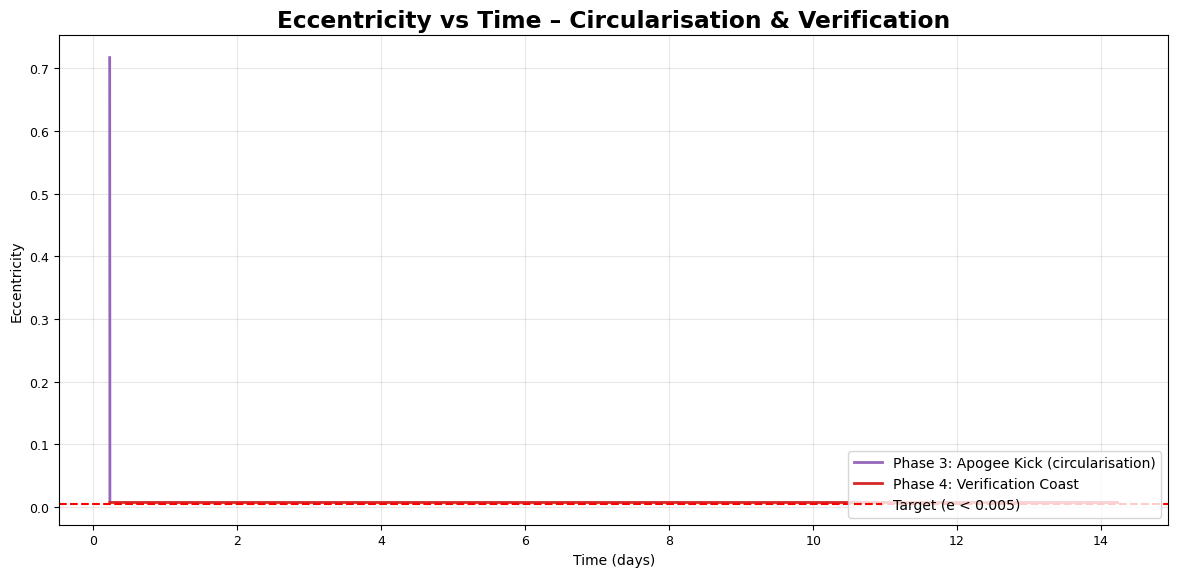

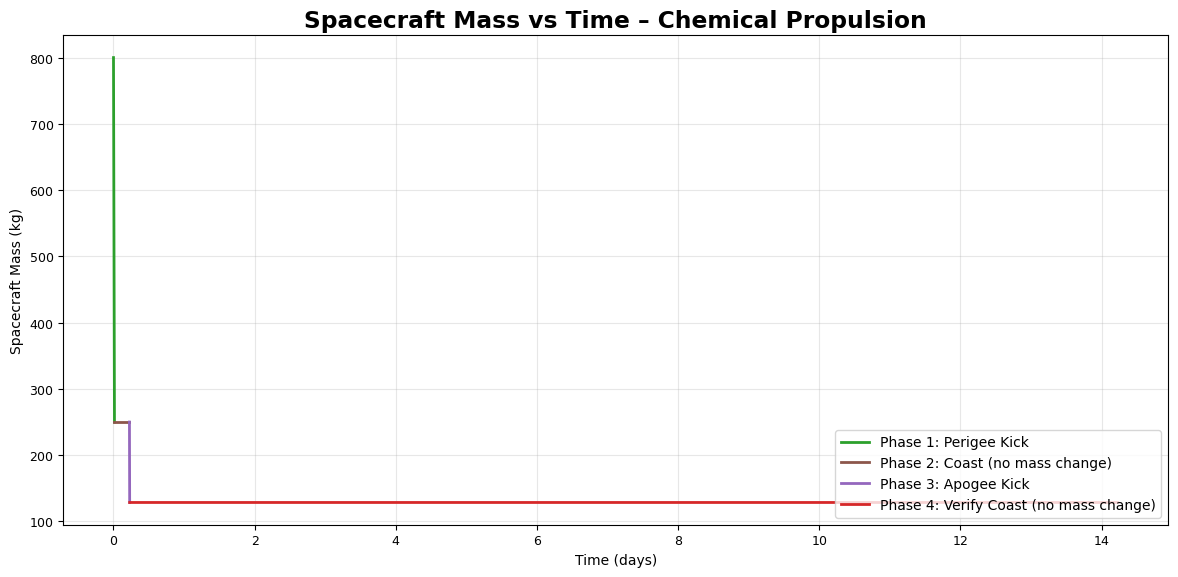

In [10]:
import os
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle

from Basilisk import __path__
from Basilisk.architecture import messaging
from Basilisk.simulation import spacecraft
from Basilisk.simulation import extForceTorque
from Basilisk.simulation import simpleNav
from Basilisk.utilities import SimulationBaseClass
from Basilisk.utilities import macros
from Basilisk.utilities import unitTestSupport
from Basilisk.utilities import simIncludeGravBody

bskPath = __path__[0]


def run(show_plots=True):
    """
    Main simulation function for LEO to GEO chemical propulsion transfer.

    Strategy (Hohmann-like, 3-burn sequence):
      Burn 1  – Perigee kick: raises apogee from LEO to GEO altitude
      Coast   – Half-ellipse coast from perigee to apogee
      Burn 2  – Apogee kick: circularises the transfer orbit at GEO altitude
      Verification coast – 14-day drift to confirm orbit stability

    """

    # ------------------------------------------------------------------ #
    # Constants
    # ------------------------------------------------------------------ #
    R_E  = 6378.0          # km  – Earth radius
    mu   = 3.986e5         # km³/s² – Earth gravitational parameter

    # Initial orbit (circular LEO)
    a_init  = 278.0        # km altitude
    r_init  = a_init + R_E # km radius
    v_init  = np.sqrt(mu / r_init)  # km/s

    # Target orbit (circular GEO)
    a_final  = 35786.0     # km altitude
    r_final  = a_final + R_E
    v_final  = np.sqrt(mu / r_final)  # km/s

    # Spacecraft
    m_0 =800.0           # kg – initial wet mass

    # ------------------------------------------------------------------ #
    # Chemical engine parameters
    # ------------------------------------------------------------------ #
    T    = 1000.0 / 1000.0  # kN  
    I_sp = 220.0           # s   
    g_0  = 9.807e-3        # km/s²  gravity

    # ------------------------------------------------------------------ #
    # Hohmann transfer Δv budget (ideal impulsive, for reference only)
    # ------------------------------------------------------------------ #
    r_t_peri = r_init
    r_t_apo  = r_final
    a_t      = (r_t_peri + r_t_apo) / 2.0

    v_t_peri = np.sqrt(mu * (2.0 / r_t_peri - 1.0 / a_t))
    v_t_apo  = np.sqrt(mu * (2.0 / r_t_apo  - 1.0 / a_t))

    dv1_ideal = v_t_peri - v_init
    dv2_ideal = v_final  - v_t_apo
    dv_total_ideal = dv1_ideal + dv2_ideal

    # ------------------------------------------------------------------ #
    # Finite-burn correction for Burn 1 (perigee kick)
    # ------------------------------------------------------------------ #

    def simulate_burn_apogee(dv_target, r0, v0, m0, T_kN, Isp, g0, mu_val, dt=1.0):
        # Simulate a tangential finite burn from a circular orbit (r0, v0).
        # Accumulates Δv = (T/m)*dt using mass at START of each step (correct
        # Tsiolkovsky-consistent integration).  Returns post-burn apogee radius.
        r_vec  = np.array([r0, 0.0, 0.0])
        v_vec  = np.array([0.0, v0, 0.0])
        m      = m0
        dv_acc = 0.0
        mdot   = T_kN / (Isp * g0)   # kg/s  (T_kN in kN, g0 in km/s²)

        while dv_acc < dv_target:
            r_mag = np.linalg.norm(r_vec)
            v_mag = np.linalg.norm(v_vec)

            # ---- accumulate dv BEFORE updating mass (fixes the bug) ----
            dv_step = (T_kN / m) * dt       # km/s, uses current mass
            dv_acc += dv_step

            # Clamp last step so don't overshoot dv_target
            if dv_acc > dv_target:
                dt_actual = (dv_target - (dv_acc - dv_step)) / (T_kN / m)
            else:
                dt_actual = dt

            # Accelerations
            a_grav     = -mu_val / r_mag**3 * r_vec
            thrust_acc = (T_kN / m) * (v_vec / v_mag)

            # Euler integration with actual dt
            v_vec = v_vec + (a_grav + thrust_acc) * dt_actual
            r_vec = r_vec + v_vec * dt_actual
            m     = max(m - mdot * dt_actual, 1.0)

        # Compute post-burn apogee from vis-viva + eccentricity
        r_mag  = np.linalg.norm(r_vec)
        v_mag  = np.linalg.norm(v_vec)
        spec_e = v_mag**2 / 2.0 - mu_val / r_mag
        if spec_e >= 0:
            return 1e9   # escape orbit — flag for bisection
        a_orb  = -mu_val / (2.0 * spec_e)
        h_vec  = np.cross(r_vec, v_vec)
        e_vec  = np.cross(v_vec, h_vec) / mu_val - r_vec / r_mag
        e_mag  = np.linalg.norm(e_vec)
        return a_orb * (1.0 + e_mag)

    # ------------------------------------------------------------------
    # Bisect on dv_target until simulated post-burn apogee = r_final ± 1 km.
    #
    # Upper bound: for very low T/W the burn takes a long time and the
    # spacecraft rises a lot, so we need a wider search range.
    # Estimate max possible dv as Tsiolkovsky limit (full tank burn).
    dv_max_possible = I_sp * g_0 * np.log(m_0 / max(m_0 * 0.05, 1.0))
    dv_lo = dv1_ideal * 0.9          # slightly below ideal (finite burn gains altitude → less dv needed)
    dv_hi = min(dv1_ideal * 2.0, dv_max_possible)  # generous upper bound

    # Quick sanity: confirm upper bound actually reaches r_final
    r_apo_hi = simulate_burn_apogee(dv_hi, r_init, v_init, m_0, T, I_sp, g_0, mu)
    if r_apo_hi < r_final:
        # T/W so low that even burning all propellant won't reach GEO in one burn.
        # Fall back to the ideal Δv — finite-burn gravity losses dominate and
        # the correction is not meaningful; just use impulsive value.
        dv1_corrected = dv1_ideal
        print(f"WARNING: T/W={T*1000/(m_0*9.807e-3*1000):.4f} is very low — finite-burn correction")
        print(f"  not achievable in one burn. Using ideal Δv as best estimate.")
    else:
        dv1_corrected = dv1_ideal   # starting guess
        for _ in range(50):
            dv_mid    = (dv_lo + dv_hi) / 2.0
            r_apo_sim = simulate_burn_apogee(dv_mid, r_init, v_init, m_0, T, I_sp, g_0, mu)
            if r_apo_sim < r_final:
                dv_lo = dv_mid
            else:
                dv_hi = dv_mid
            if abs(r_apo_sim - r_final) < 1.0:
                break
        dv1_corrected = dv_mid

    print(f"Burn 1 Δv ideal             : {dv1_ideal:.4f} km/s")
    print(f"Burn 1 Δv finite-corrected  : {dv1_corrected:.4f} km/s")
    print(f"T/W ratio at ignition       : {T*1000 / (m_0 * 9.807e-3 * 1000):.4f}  (ideal impulsive > 0.1)")

    # ------------------------------------------------------------------ #
    print("=" * 62)
    print("LEO to GEO Chemical Propulsion Transfer – Basilisk")
    print("=" * 62)
    print(f"Initial Altitude   : {a_init} km")
    print(f"Final Altitude     : {a_final} km")
    print(f"Thrust             : {T*1000:.0f} N")
    print(f"Specific Impulse   : {I_sp} s")
    print(f"Initial Mass       : {m_0} kg")
    print(f"Initial Speed      : {v_init:.4f} km/s")
    print(f"Target Speed (GEO) : {v_final:.4f} km/s")
    print(f"\nIdeal Δv₁ (perigee kick) : {dv1_ideal:.4f} km/s")
    print(f"Ideal Δv₂ (apogee  kick) : {dv2_ideal:.4f} km/s")
    print(f"Ideal Δv total           : {dv_total_ideal:.4f} km/s")
    print(f"Corrected Δv₁ (finite)   : {dv1_corrected:.4f} km/s")
    print("=" * 62)

    # ------------------------------------------------------------------ #
    # Simulation bookkeeping helpers
    # ------------------------------------------------------------------ #
    dynTaskName   = "dynTask"
    dynProcessName = "dynProcess"

    I_inertia = [900., 0., 0.,
                 0., 800., 0.,
                 0., 0., 600.]

    simTimeStep   = macros.sec2nano(1.0)   # 1-second integrator step
    updateInterval = macros.sec2nano(1.0)  # burn control at 1-second cadence

    # ================================================================== #
    # PHASE 1 – PERIGEE KICK BURN (raises apogee to GEO)
    # ================================================================== #
    print("\n" + "=" * 62)
    print("PHASE 1 – Perigee Kick Burn")
    print("=" * 62)

    scSim1 = SimulationBaseClass.SimBaseClass()
    dynProc1 = scSim1.CreateNewProcess(dynProcessName + "_p1")
    dynProc1.addTask(scSim1.CreateNewTask(dynTaskName + "_p1", simTimeStep))

    scObj1 = spacecraft.Spacecraft()
    scObj1.ModelTag = "ChemSC_Burn1"
    scObj1.hub.mHub = m_0
    scObj1.hub.r_BcB_B = [[0.0], [0.0], [0.0]]
    scObj1.hub.IHubPntBc_B = unitTestSupport.np2EigenMatrix3d(I_inertia)
    scObj1.hub.r_CN_NInit  = [[r_init * 1000.0], [0.0], [0.0]]   # m
    scObj1.hub.v_CN_NInit  = [[0.0], [v_init * 1000.0], [0.0]]   # m/s
    scObj1.hub.sigma_BNInit = [[0.0], [0.0], [0.0]]
    scObj1.hub.omega_BN_BInit = [[0.0], [0.0], [0.0]]
    scSim1.AddModelToTask(dynTaskName + "_p1", scObj1)

    gF1 = simIncludeGravBody.gravBodyFactory()
    e1  = gF1.createEarth()
    e1.isCentralBody = True
    e1.mu = mu * 1e9
    gF1.addBodiesTo(scObj1)

    extFT1 = extForceTorque.ExtForceTorque()
    extFT1.ModelTag = "thruster_burn1"
    scObj1.addDynamicEffector(extFT1)
    scSim1.AddModelToTask(dynTaskName + "_p1", extFT1)

    sNav1 = simpleNav.SimpleNav()
    sNav1.ModelTag = "Nav1"
    scSim1.AddModelToTask(dynTaskName + "_p1", sNav1)
    sNav1.scStateInMsg.subscribeTo(scObj1.scStateOutMsg)

    scSim1.InitializeSimulation()

    # Storage
    burn1_positions  = []
    burn1_velocities = []
    burn1_times      = []
    burn1_masses     = []

    # Burn 1 termination: stop when accumulated Δv equals the ideal perigee-kick Δv.
    # We track Δv as sum of (T/m)*dt each step — this is the correct finite-burn
    # criterion and is independent of the absolute speed (which changes due to
    # gravity doing work during the burn).
    dv1_accumulated = 0.0  # km/s

    current_time_b1 = 0
    # Hard cap: at least 3× the Tsiolkovsky burn-time estimate to handle low T/W
    mdot_b1        = T / (I_sp * g_0)
    m_prop_b1_est  = m_0 * (1.0 - np.exp(-dv1_corrected / (I_sp * g_0)))
    t_burn1_est    = m_prop_b1_est / mdot_b1          # seconds
    max_burn1_time = macros.sec2nano(max(t_burn1_est * 2.0, 7200.0))
    print(f"Estimated Burn 1 duration   : {t_burn1_est:.0f} s  ({t_burn1_est/60:.1f} min)")
    burn1_complete  = False

    while current_time_b1 < max_burn1_time and not burn1_complete:
        scSim1.ConfigureStopTime(current_time_b1 + updateInterval)
        scSim1.ExecuteSimulation()

        r_BN = scObj1.dynManager.getStateObject("hubPosition").getState()
        v_BN = scObj1.dynManager.getStateObject("hubVelocity").getState()
        m_cur = scObj1.hub.mHub

        r_vec = np.array([r_BN[0][0], r_BN[1][0], r_BN[2][0]]) / 1000.0
        v_vec = np.array([v_BN[0][0], v_BN[1][0], v_BN[2][0]]) / 1000.0
        v_mag = np.linalg.norm(v_vec)

        burn1_positions.append(r_vec.copy())
        burn1_velocities.append(v_vec.copy())
        burn1_times.append(current_time_b1 * macros.NANO2SEC)
        burn1_masses.append(m_cur)

        # Accumulate delivered Δv = (T / m) * dt  [km/s]
        dt = updateInterval * macros.NANO2SEC   # seconds
        dv_step = (T / m_cur) * dt              # T in kN, m in kg → km/s
        dv1_accumulated += dv_step

        if dv1_accumulated >= dv1_corrected:
            burn1_complete = True
            extFT1.extForce_N = [[0.0], [0.0], [0.0]]
            print(f"Burn 1 complete at t = {current_time_b1 * macros.NANO2SEC:.1f} s")
            print(f"  Δv delivered   : {dv1_accumulated:.4f} km/s  (corrected target {dv1_corrected:.4f} km/s)")
            print(f"  Speed achieved : {v_mag:.4f} km/s")
            print(f"  Radius         : {np.linalg.norm(r_vec):.2f} km")
            print(f"  Mass remaining : {m_cur:.2f} kg")
            break

        # Thrust in velocity direction (tangential)
        if v_mag > 0:
            thrust_dir = v_vec / v_mag
            F_N = T * 1000.0 * thrust_dir          # N (T is in kN)
            extFT1.extForce_N = [[F_N[0]], [F_N[1]], [F_N[2]]]
        else:
            extFT1.extForce_N = [[0.0], [0.0], [0.0]]

        # Tsiolkovsky mass flow
        dm = -T / (I_sp * g_0) * dt
        scObj1.hub.mHub = max(10.0, m_cur + dm)

        current_time_b1 += updateInterval

    burn1_end_time_sec = current_time_b1 * macros.NANO2SEC
    m_after_burn1 = scObj1.hub.mHub
    propellant_burn1 = m_0 - m_after_burn1

    burn1_positions  = np.array(burn1_positions)
    burn1_velocities = np.array(burn1_velocities)

    # ================================================================== #
    # PHASE 2 – COAST (half ellipse, perigee → apogee)
    # ================================================================== #
    print("\n" + "=" * 62)
    print("PHASE 2 – Coast (transfer ellipse, perigee → apogee)")
    print("=" * 62)

    r_BN_p2 = scObj1.dynManager.getStateObject("hubPosition").getState()
    v_BN_p2 = scObj1.dynManager.getStateObject("hubVelocity").getState()

    scSim2 = SimulationBaseClass.SimBaseClass()
    dynProc2 = scSim2.CreateNewProcess(dynProcessName + "_p2")
    dynProc2.addTask(scSim2.CreateNewTask(dynTaskName + "_p2", simTimeStep))

    scObj2 = spacecraft.Spacecraft()
    scObj2.ModelTag = "ChemSC_Coast"
    scObj2.hub.mHub = m_after_burn1
    scObj2.hub.r_BcB_B = [[0.0], [0.0], [0.0]]
    scObj2.hub.IHubPntBc_B = unitTestSupport.np2EigenMatrix3d(I_inertia)
    scObj2.hub.r_CN_NInit  = r_BN_p2
    scObj2.hub.v_CN_NInit  = v_BN_p2
    scObj2.hub.sigma_BNInit = [[0.0], [0.0], [0.0]]
    scObj2.hub.omega_BN_BInit = [[0.0], [0.0], [0.0]]
    scSim2.AddModelToTask(dynTaskName + "_p2", scObj2)

    gF2 = simIncludeGravBody.gravBodyFactory()
    e2  = gF2.createEarth()
    e2.isCentralBody = True
    e2.mu = mu * 1e9
    gF2.addBodiesTo(scObj2)

    sNav2 = simpleNav.SimpleNav()
    sNav2.ModelTag = "Nav2"
    scSim2.AddModelToTask(dynTaskName + "_p2", sNav2)
    sNav2.scStateInMsg.subscribeTo(scObj2.scStateOutMsg)

    scSim2.InitializeSimulation()

    coast_positions  = []
    coast_velocities = []
    coast_times      = []

    # ------------------------------------------------------------------ #
    # Two-pass coast strategy for centering Burn 2 on apogee:
    #
    # Pass 1 (coarse, 60 s steps): find the approximate apogee time t_apo.
    # Then estimate Burn 2 duration from Tsiolkovsky so we know how far
    # before apogee to start firing.  Coast only to t_apo - burn2_half, so
    # the midpoint of Burn 2 coincides with apogee.  This eliminates the
    # systematic under-circularisation caused by firing entirely after apogee.
    # ------------------------------------------------------------------ #

    # --- Pass 1: coarse scan to locate apogee time ----------------------
    current_time_c = 0
    max_coast_time  = macros.day2nano(1.0)
    coast_interval  = macros.sec2nano(60.0)

    last_r_mag_c  = 0.0
    apogee_found  = False
    t_apo_nano    = 0      # will hold apogee time in nanoseconds
    r_apo_pass1   = 0.0
    v_apo_pass1   = 0.0

    while current_time_c < max_coast_time and not apogee_found:
        scSim2.ConfigureStopTime(current_time_c + coast_interval)
        scSim2.ExecuteSimulation()

        r_BN = scObj2.dynManager.getStateObject("hubPosition").getState()
        v_BN = scObj2.dynManager.getStateObject("hubVelocity").getState()

        r_vec = np.array([r_BN[0][0], r_BN[1][0], r_BN[2][0]]) / 1000.0
        v_vec = np.array([v_BN[0][0], v_BN[1][0], v_BN[2][0]]) / 1000.0
        r_mag = np.linalg.norm(r_vec)
        v_mag = np.linalg.norm(v_vec)

        coast_positions.append(r_vec.copy())
        coast_velocities.append(v_vec.copy())
        coast_times.append(burn1_end_time_sec + current_time_c * macros.NANO2SEC)

        if last_r_mag_c > 0 and r_mag < last_r_mag_c:
            apogee_found = True
            # Apogee was between the previous step and this one; use prev step
            # (last maximum) as the apogee state
            t_apo_nano  = current_time_c - coast_interval
            r_apo_pass1 = last_r_mag_c
            v_apo_pass1 = np.linalg.norm(coast_velocities[-2])
            print(f"Apogee located at t_coast = {t_apo_nano * macros.NANO2SEC / 3600.0:.2f} h")
            print(f"  Apogee radius   : {r_apo_pass1:.2f} km  (altitude {r_apo_pass1 - R_E:.2f} km)")
            print(f"  Speed at apogee : {v_apo_pass1:.4f} km/s")
            break

        last_r_mag_c = r_mag
        current_time_c += coast_interval

    # --- Compute adaptive Δv₂ from actual apogee state ------------------
    #
    # Circularise at the actual apogee — not the ideal GEO altitude — so
    # the burn is self-consistent with whatever transfer orbit Burn 1 created.
    r_apo_actual  = r_apo_pass1
    v_apo_actual  = v_apo_pass1
    v_circ_actual = np.sqrt(mu / r_apo_actual)
    dv2_actual    = v_circ_actual - v_apo_actual

    print(f"\nActual apogee radius    : {r_apo_actual:.2f} km  (target {r_final:.2f} km)")
    print(f"Circular speed there    : {v_circ_actual:.4f} km/s")
    print(f"Current speed at apogee : {v_apo_actual:.4f} km/s")
    print(f"Adaptive Δv₂            : {dv2_actual:.4f} km/s  (ideal was {dv2_ideal:.4f} km/s)")

    # --- Estimate Burn 2 duration to compute the half-burn offset -------
    #
    # Tsiolkovsky rocket equation gives propellant mass for dv2_actual:
    #   m_prop = m_after_burn1 * (1 - exp(-dv2_actual / (Isp * g0)))
    # Burn time ≈ m_prop / (T / (Isp * g0))  [constant-thrust approximation]
    m_prop_b2_est  = m_after_burn1 * (1.0 - np.exp(-dv2_actual / (I_sp * g_0)))
    mdot           = T / (I_sp * g_0)          # kg/s
    t_burn2_est    = m_prop_b2_est / mdot       # seconds
    t_half_burn2   = t_burn2_est / 2.0          # seconds — offset before apogee

    print(f"Estimated Burn 2 duration : {t_burn2_est:.1f} s  ({t_burn2_est/60:.2f} min)")
    print(f"Will start Burn 2 at      : {t_half_burn2:.1f} s before apogee")

    # --- Resume coast to (t_apo - half_burn) ----------------------------
    #
    # We already coasted past apogee in Pass 1.  We need to back up and
    # restart the coast simulation stopping at the correct ignition time.
    # Easiest approach: create a fresh coast sim from burn-1-end to
    # t_ignition = t_apo - t_half_burn2.
    t_ignition_nano = max(0, t_apo_nano - macros.sec2nano(t_half_burn2))

    # Re-initialise coast simulation from burn 1 end state
    r_BN_p2_fresh = scObj1.dynManager.getStateObject("hubPosition").getState()
    v_BN_p2_fresh = scObj1.dynManager.getStateObject("hubVelocity").getState()

    scSim2b = SimulationBaseClass.SimBaseClass()
    dynProc2b = scSim2b.CreateNewProcess(dynProcessName + "_p2b")
    dynProc2b.addTask(scSim2b.CreateNewTask(dynTaskName + "_p2b", simTimeStep))

    scObj2b = spacecraft.Spacecraft()
    scObj2b.ModelTag = "ChemSC_Coast2b"
    scObj2b.hub.mHub = m_after_burn1
    scObj2b.hub.r_BcB_B = [[0.0], [0.0], [0.0]]
    scObj2b.hub.IHubPntBc_B = unitTestSupport.np2EigenMatrix3d(I_inertia)
    scObj2b.hub.r_CN_NInit  = r_BN_p2_fresh
    scObj2b.hub.v_CN_NInit  = v_BN_p2_fresh
    scObj2b.hub.sigma_BNInit = [[0.0], [0.0], [0.0]]
    scObj2b.hub.omega_BN_BInit = [[0.0], [0.0], [0.0]]
    scSim2b.AddModelToTask(dynTaskName + "_p2b", scObj2b)

    gF2b = simIncludeGravBody.gravBodyFactory()
    e2b  = gF2b.createEarth()
    e2b.isCentralBody = True
    e2b.mu = mu * 1e9
    gF2b.addBodiesTo(scObj2b)

    sNav2b = simpleNav.SimpleNav()
    sNav2b.ModelTag = "Nav2b"
    scSim2b.AddModelToTask(dynTaskName + "_p2b", sNav2b)
    sNav2b.scStateInMsg.subscribeTo(scObj2b.scStateOutMsg)

    scSim2b.InitializeSimulation()

    # Coast to ignition point
    scSim2b.ConfigureStopTime(t_ignition_nano)
    scSim2b.ExecuteSimulation()

    r_BN_at_ignition = scObj2b.dynManager.getStateObject("hubPosition").getState()
    v_BN_at_ignition = scObj2b.dynManager.getStateObject("hubVelocity").getState()
    r_ign = np.linalg.norm(np.array([r_BN_at_ignition[i][0] for i in range(3)])) / 1000.0
    v_ign = np.linalg.norm(np.array([v_BN_at_ignition[i][0] for i in range(3)])) / 1000.0
    print(f"Burn 2 ignition point     : radius {r_ign:.2f} km, speed {v_ign:.4f} km/s")

    coast_end_time_sec = burn1_end_time_sec + t_ignition_nano * macros.NANO2SEC

    # Replace the coast arrays with the trimmed version up to ignition
    # (keep Pass 1 data only up to ignition for plotting continuity)
    ign_idx = int(t_ignition_nano / coast_interval)
    coast_positions  = np.array(coast_positions[:ign_idx])
    coast_velocities = np.array(coast_velocities[:ign_idx])
    coast_times      = coast_times[:ign_idx]

    # ================================================================== #
    # PHASE 3 – APOGEE KICK BURN (circularise at GEO)
    # ================================================================== #
    print("\n" + "=" * 62)
    print("PHASE 3 – Apogee Kick Burn (circularisation)")
    print("=" * 62)

    # Use state from the refined coast (scObj2b), which stopped at ignition point
    r_BN_p3 = scObj2b.dynManager.getStateObject("hubPosition").getState()
    v_BN_p3 = scObj2b.dynManager.getStateObject("hubVelocity").getState()

    scSim3 = SimulationBaseClass.SimBaseClass()
    dynProc3 = scSim3.CreateNewProcess(dynProcessName + "_p3")
    dynProc3.addTask(scSim3.CreateNewTask(dynTaskName + "_p3", simTimeStep))

    scObj3 = spacecraft.Spacecraft()
    scObj3.ModelTag = "ChemSC_Burn2"
    scObj3.hub.mHub = m_after_burn1
    scObj3.hub.r_BcB_B = [[0.0], [0.0], [0.0]]
    scObj3.hub.IHubPntBc_B = unitTestSupport.np2EigenMatrix3d(I_inertia)
    scObj3.hub.r_CN_NInit  = r_BN_p3
    scObj3.hub.v_CN_NInit  = v_BN_p3
    scObj3.hub.sigma_BNInit = [[0.0], [0.0], [0.0]]
    scObj3.hub.omega_BN_BInit = [[0.0], [0.0], [0.0]]
    scSim3.AddModelToTask(dynTaskName + "_p3", scObj3)

    gF3 = simIncludeGravBody.gravBodyFactory()
    e3  = gF3.createEarth()
    e3.isCentralBody = True
    e3.mu = mu * 1e9
    gF3.addBodiesTo(scObj3)

    extFT3 = extForceTorque.ExtForceTorque()
    extFT3.ModelTag = "thruster_burn2"
    scObj3.addDynamicEffector(extFT3)
    scSim3.AddModelToTask(dynTaskName + "_p3", extFT3)

    sNav3 = simpleNav.SimpleNav()
    sNav3.ModelTag = "Nav3"
    scSim3.AddModelToTask(dynTaskName + "_p3", sNav3)
    sNav3.scStateInMsg.subscribeTo(scObj3.scStateOutMsg)

    scSim3.InitializeSimulation()

    burn2_positions  = []
    burn2_velocities = []
    burn2_times      = []
    burn2_masses     = []

    # Burn 2 termination: stop when accumulated Δv equals the ideal apogee-kick Δv.
    # Using the same Δv-accumulation logic as Burn 1 for consistency and correctness.
    # Eccentricity is computed for logging only — not used as the stop criterion.
    ECCENTRICITY_TARGET = 0.005   # for reporting/plotting reference
    dv2_accumulated = 0.0  # km/s
    current_time_b2 = 0
    max_burn2_time  = macros.sec2nano(7200.0)  # 2-hour hard cap
    burn2_complete  = False

    while current_time_b2 < max_burn2_time and not burn2_complete:
        scSim3.ConfigureStopTime(current_time_b2 + updateInterval)
        scSim3.ExecuteSimulation()

        r_BN = scObj3.dynManager.getStateObject("hubPosition").getState()
        v_BN = scObj3.dynManager.getStateObject("hubVelocity").getState()
        m_cur = scObj3.hub.mHub

        r_vec = np.array([r_BN[0][0], r_BN[1][0], r_BN[2][0]]) / 1000.0
        v_vec = np.array([v_BN[0][0], v_BN[1][0], v_BN[2][0]]) / 1000.0
        r_mag = np.linalg.norm(r_vec)
        v_mag = np.linalg.norm(v_vec)

        burn2_positions.append(r_vec.copy())
        burn2_velocities.append(v_vec.copy())
        burn2_times.append(coast_end_time_sec + current_time_b2 * macros.NANO2SEC)
        burn2_masses.append(m_cur)

        # Orbital elements (for logging / plotting)
        h_vec = np.cross(r_vec, v_vec)
        e_vec = np.cross(v_vec, h_vec) / mu - r_vec / r_mag
        e_mag = np.linalg.norm(e_vec)
        spec_energy = v_mag**2 / 2.0 - mu / r_mag
        if spec_energy < 0:
            a_cur = -mu / (2.0 * spec_energy)
            r_apo = a_cur * (1.0 + e_mag)
        else:
            r_apo = r_mag

        # Accumulate delivered Δv and check stop criterion
        dt = updateInterval * macros.NANO2SEC
        dv_step = (T / m_cur) * dt      # km/s
        dv2_accumulated += dv_step

        if dv2_accumulated >= dv2_actual:
            burn2_complete = True
            extFT3.extForce_N = [[0.0], [0.0], [0.0]]
            print(f"Burn 2 complete at t = {current_time_b2 * macros.NANO2SEC:.1f} s")
            print(f"  Δv delivered   : {dv2_accumulated:.4f} km/s  (adaptive target {dv2_actual:.4f} km/s)")
            print(f"  Eccentricity   : {e_mag:.6f}  (reference target < {ECCENTRICITY_TARGET})")
            print(f"  Apogee radius  : {r_apo:.2f} km  (alt {r_apo - R_E:.2f} km)")
            print(f"  Speed          : {v_mag:.4f} km/s  (target {v_final:.4f} km/s)")
            print(f"  Radius         : {r_mag:.2f} km  (alt {r_mag - R_E:.2f} km)")
            print(f"  Mass remaining : {m_cur:.2f} kg")
            break

        # Check fuel
        if m_cur - 10.0 < 1.0:
            burn2_complete = True
            extFT3.extForce_N = [[0.0], [0.0], [0.0]]
            print("Burn 2 stopped – fuel depleted.")
            break

        # Thrust tangentially
        if v_mag > 0:
            thrust_dir = v_vec / v_mag
            F_N = T * 1000.0 * thrust_dir
            extFT3.extForce_N = [[F_N[0]], [F_N[1]], [F_N[2]]]
        else:
            extFT3.extForce_N = [[0.0], [0.0], [0.0]]

        dm = -T / (I_sp * g_0) * dt
        scObj3.hub.mHub = max(10.0, m_cur + dm)

        current_time_b2 += updateInterval

    burn2_end_time_sec = coast_end_time_sec + current_time_b2 * macros.NANO2SEC
    m_after_burn2 = scObj3.hub.mHub
    propellant_burn2 = m_after_burn1 - m_after_burn2
    total_propellant = m_0 - m_after_burn2

    burn2_positions  = np.array(burn2_positions)
    burn2_velocities = np.array(burn2_velocities)

    # Final state from burn 2 for reporting
    final_r_vec = burn2_positions[-1]
    final_v_vec = burn2_velocities[-1]
    final_r_mag = np.linalg.norm(final_r_vec)
    final_v_mag = np.linalg.norm(final_v_vec)
    h_f = np.cross(final_r_vec, final_v_vec)
    e_f_vec = np.cross(final_v_vec, h_f) / mu - final_r_vec / final_r_mag
    final_ecc = np.linalg.norm(e_f_vec)

    # ================================================================== #
    # PHASE 4 – VERIFICATION COAST (14 days, confirm orbit stability)
    # ================================================================== #
    print("\n" + "=" * 62)
    print("PHASE 4 – Verification Coast (14 days)")
    print("=" * 62)

    r_BN_p4 = scObj3.dynManager.getStateObject("hubPosition").getState()
    v_BN_p4 = scObj3.dynManager.getStateObject("hubVelocity").getState()

    scSim4 = SimulationBaseClass.SimBaseClass()
    dynProc4 = scSim4.CreateNewProcess(dynProcessName + "_p4")
    dynProc4.addTask(scSim4.CreateNewTask(dynTaskName + "_p4", simTimeStep))

    scObj4 = spacecraft.Spacecraft()
    scObj4.ModelTag = "ChemSC_Verify"
    scObj4.hub.mHub = m_after_burn2
    scObj4.hub.r_BcB_B = [[0.0], [0.0], [0.0]]
    scObj4.hub.IHubPntBc_B = unitTestSupport.np2EigenMatrix3d(I_inertia)
    scObj4.hub.r_CN_NInit  = r_BN_p4
    scObj4.hub.v_CN_NInit  = v_BN_p4
    scObj4.hub.sigma_BNInit = [[0.0], [0.0], [0.0]]
    scObj4.hub.omega_BN_BInit = [[0.0], [0.0], [0.0]]
    scSim4.AddModelToTask(dynTaskName + "_p4", scObj4)

    gF4 = simIncludeGravBody.gravBodyFactory()
    e4  = gF4.createEarth()
    e4.isCentralBody = True
    e4.mu = mu * 1e9
    gF4.addBodiesTo(scObj4)

    sNav4 = simpleNav.SimpleNav()
    sNav4.ModelTag = "Nav4"
    scSim4.AddModelToTask(dynTaskName + "_p4", sNav4)
    sNav4.scStateInMsg.subscribeTo(scObj4.scStateOutMsg)

    coast_sample = macros.sec2nano(600.0)
    scStateLog4 = scObj4.scStateOutMsg.recorder(coast_sample)
    scSim4.AddModelToTask(dynTaskName + "_p4", scStateLog4)

    scSim4.InitializeSimulation()

    t_verify = macros.day2nano(14.0)
    scSim4.ConfigureStopTime(t_verify)
    scSim4.ExecuteSimulation()

    # Extract logged data
    verify_times_nano = scStateLog4.times()
    verify_r = scStateLog4.r_BN_N / 1000.0   # km
    verify_v = scStateLog4.v_BN_N / 1000.0   # km/s

    verify_positions  = [verify_r[i]  for i in range(len(verify_times_nano))]
    verify_velocities = [verify_v[i]  for i in range(len(verify_times_nano))]
    verify_times      = [burn2_end_time_sec + verify_times_nano[i] * macros.NANO2SEC
                         for i in range(len(verify_times_nano))]

    verify_positions  = np.array(verify_positions)
    verify_velocities = np.array(verify_velocities)

    # Orbit quality metrics
    verify_radii = [np.linalg.norm(r) for r in verify_positions]
    r_v_apo = max(verify_radii)
    r_v_per = min(verify_radii)
    r_v_avg = (r_v_apo + r_v_per) / 2.0
    e_verify = (r_v_apo - r_v_per) / (r_v_apo + r_v_per)
    r_error_pct = (r_v_avg - r_final) / r_final * 100.0

    verify_eccentricities = []
    for rv, vv in zip(verify_positions, verify_velocities):
        rmag = np.linalg.norm(rv); vmag = np.linalg.norm(vv)
        hv = np.cross(rv, vv)
        ev = np.cross(vv, hv) / mu - rv / rmag
        verify_eccentricities.append(np.linalg.norm(ev))

    e_v_mean = np.mean(verify_eccentricities)
    e_v_std  = np.std(verify_eccentricities)

    coast_end_total_sec = burn2_end_time_sec + t_verify * macros.NANO2SEC

    # ================================================================== #
    # SUMMARY
    # ================================================================== #
    print("\n" + "=" * 62)
    print("SIMULATION COMPLETE – FINAL RESULTS")
    print("=" * 62)
    print(f"Initial Altitude       : {a_init} km")
    print(f"Target  Altitude       : {a_final} km")
    print(f"Thrust                 : {T*1000:.0f} N")
    print(f"Specific Impulse       : {I_sp} s")
    print()
    print(f"Ideal Δv₁              : {dv1_ideal:.4f} km/s")
    print(f"Ideal Δv₂              : {dv2_ideal:.4f} km/s")
    print(f"Ideal Δv total         : {dv_total_ideal:.4f} km/s")
    print(f"Adaptive Δv₂ (actual)  : {dv2_actual:.4f} km/s")
    print()
    print("PHASE 1 – PERIGEE KICK BURN:")
    print(f"  Duration             : {burn1_end_time_sec:.1f} s  ({burn1_end_time_sec/60:.2f} min)")
    print(f"  Propellant used      : {propellant_burn1:.4f} kg")
    print(f"  Speed after burn     : {np.linalg.norm(burn1_velocities[-1]):.4f} km/s")
    print()
    print("PHASE 2 – COAST (perigee → apogee):")
    print(f"  Duration             : {current_time_c * macros.NANO2SEC / 3600.0:.2f} h")
    print(f"  Apogee altitude      : {np.linalg.norm(coast_positions[-1]) - R_E:.2f} km")
    print(f"  Speed at apogee      : {np.linalg.norm(coast_velocities[-1]):.4f} km/s")
    print()
    print("PHASE 3 – APOGEE KICK BURN (circularisation):")
    print(f"  Duration             : {current_time_b2 * macros.NANO2SEC:.1f} s  ({current_time_b2 * macros.NANO2SEC/60:.2f} min)")
    print(f"  Propellant used      : {propellant_burn2:.4f} kg")
    print(f"  Final eccentricity   : {final_ecc:.6f}")
    print(f"  Final altitude       : {final_r_mag - R_E:.2f} km")
    print(f"  Final speed          : {final_v_mag:.4f} km/s")
    print()
    print("PHASE 4 – VERIFICATION COAST (14 days):")
    print(f"  Mean eccentricity    : {e_v_mean:.6f}")
    print(f"  Eccentricity std dev : {e_v_std:.8f}")
    print(f"  Orbit radius error   : {r_error_pct:.4f} %")
    print()
    print("TOTAL MISSION:")
    print(f"  Total propellant used: {total_propellant:.4f} kg  (Δm/m₀ = {total_propellant/m_0*100:.2f} %)")
    m_prop_tsiolkovsky = m_0 * (1.0 - np.exp(-dv_total_ideal / (I_sp * g_0)))
    print(f"  Tsiolkovsky prediction ({dv_total_ideal:.3f} km/s, Isp={I_sp}s): {m_prop_tsiolkovsky:.1f} kg  <- this mass loss is correct for GEO")
    print(f"  Total mission time   : {coast_end_total_sec/3600.0:.2f} h  ({coast_end_total_sec/86400.0:.2f} days)")
    print(f"  Final spacecraft mass: {m_after_burn2:.2f} kg")
    print("=" * 62)

    # ================================================================== #
    # PLOTS
    # ================================================================== #
    if show_plots:
        burn1_positions  = np.array(burn1_positions)
        burn1_velocities = np.array(burn1_velocities)
        burn2_positions  = np.array(burn2_positions)
        burn2_velocities = np.array(burn2_velocities)

        summary_text = (
            f"Initial Alt  : {a_init} km\n"
            f"Target Alt   : {a_final} km\n"
            f"Thrust       : {T*1000:.0f} N\n"
            f"I_sp         : {I_sp} s\n"
            f"Ideal Δv₁    : {dv1_ideal:.4f} km/s\n"
            f"Ideal Δv₂    : {dv2_ideal:.4f} km/s\n"
            f"Propellant   : {total_propellant:.2f} kg\n"
            f"Mission time : {coast_end_total_sec/3600.0:.2f} h\n"
            f"Final ecc    : {final_ecc:.6f}\n"
            f"Final alt    : {final_r_mag - R_E:.2f} km"
        )

        # -- Plot 1: Trajectory in XY plane ---------------------------------
        plt.rc("font", size=14)
        fig, ax = plt.subplots(figsize=(14, 14))
        ax.set_aspect("equal")
        ax.axis("off")

        earth_circle = Circle((0, 0), R_E, ec="none", fc="C0")
        ax.add_patch(earth_circle)
        ax.annotate("Earth", xy=(0, 0), ha="center", va="center", color="white", fontsize=14)

        leo_circle = Circle((0, 0), r_init,  ec="grey", fc="none", lw=1, ls=":")
        geo_circle = Circle((0, 0), r_final, ec="C1",   fc="none", lw=2, ls="--")
        ax.add_patch(leo_circle)
        ax.add_patch(geo_circle)

        ax.plot(burn1_positions[:, 0], burn1_positions[:, 1],
                color="C2", lw=3, label="Phase 1: Perigee Kick Burn")
        ax.plot(coast_positions[:, 0], coast_positions[:, 1],
                color="C5", lw=2, label="Phase 2: Coast (transfer ellipse)")
        ax.plot(burn2_positions[:, 0], burn2_positions[:, 1],
                color="C4", lw=3, label="Phase 3: Apogee Kick Burn")
        ax.plot(verify_positions[:, 0], verify_positions[:, 1],
                color="C3", lw=1, label="Phase 4: Verification Coast")

        ax.legend(loc="upper right", fontsize=11)
        ax.text(0.02, 0.98, summary_text, transform=ax.transAxes,
                fontsize=10, verticalalignment="top",
                bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.85))
        ax.set_title("LEO to GEO – Chemical Propulsion (Hohmann Transfer)", fontsize=14, fontweight="bold")
        plt.tight_layout()

        # -- Plot 2: Altitude vs Time ----------------------------------------
        all_altitudes = (
            [np.linalg.norm(r) - R_E for r in burn1_positions],
            [np.linalg.norm(r) - R_E for r in coast_positions],
            [np.linalg.norm(r) - R_E for r in burn2_positions],
            [np.linalg.norm(r) - R_E for r in verify_positions],
        )
        all_t_days = (
            np.array(burn1_times) / 86400.0,
            np.array(coast_times) / 86400.0,
            np.array(burn2_times) / 86400.0,
            np.array(verify_times) / 86400.0,
        )
        labels = ["Phase 1: Perigee Kick", "Phase 2: Coast",
                  "Phase 3: Apogee Kick", "Phase 4: Verify Coast"]
        colors = ["C2", "C5", "C4", "C3"]

        plt.figure(figsize=(12, 6))
        for alt, t_d, lbl, col in zip(all_altitudes, all_t_days, labels, colors):
            plt.plot(t_d, alt, color=col, lw=2, label=lbl)
        plt.axhline(y=a_final, color="C1", ls="--", lw=1.5, label="Target GEO altitude")
        plt.xlabel("Time (days)")
        plt.ylabel("Altitude (km)")
        plt.title("Altitude vs Time – Chemical Propulsion LEO→GEO", fontweight="bold")
        plt.legend(fontsize=10)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        # -- Plot 3: Velocity vs Time ----------------------------------------
        all_velocities = (
            [np.linalg.norm(v) for v in burn1_velocities],
            [np.linalg.norm(v) for v in coast_velocities],
            [np.linalg.norm(v) for v in burn2_velocities],
            [np.linalg.norm(v) for v in verify_velocities],
        )

        plt.figure(figsize=(12, 6))
        for vel, t_d, lbl, col in zip(all_velocities, all_t_days, labels, colors):
            plt.plot(t_d, vel, color=col, lw=2, label=lbl)
        plt.axhline(y=v_final, color="C1", ls="--", lw=1.5, label="Target GEO circular speed")
        plt.xlabel("Time (days)")
        plt.ylabel("Speed (km/s)")
        plt.title("Velocity Magnitude vs Time – Chemical Propulsion", fontweight="bold")
        plt.legend(fontsize=10)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        # -- Plot 4: Eccentricity during burn 2 + verification ---------------
        burn2_eccentricities = []
        for rv, vv in zip(burn2_positions, burn2_velocities):
            rmag = np.linalg.norm(rv); vmag = np.linalg.norm(vv)
            hv = np.cross(rv, vv)
            ev = np.cross(vv, hv) / mu - rv / rmag
            burn2_eccentricities.append(np.linalg.norm(ev))

        plt.figure(figsize=(12, 6))
        plt.plot(np.array(burn2_times) / 86400.0, burn2_eccentricities,
                 color="C4", lw=2, label="Phase 3: Apogee Kick (circularisation)")
        plt.plot(np.array(verify_times) / 86400.0, verify_eccentricities,
                 color="C3", lw=2, label="Phase 4: Verification Coast")
        plt.axhline(y=ECCENTRICITY_TARGET, color="r", ls="--", lw=1.5,
                    label=f"Target (e < {ECCENTRICITY_TARGET})")
        plt.xlabel("Time (days)")
        plt.ylabel("Eccentricity")
        plt.title("Eccentricity vs Time – Circularisation & Verification", fontweight="bold")
        plt.legend(fontsize=10)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        # -- Plot 5: Spacecraft Mass vs Time ---------------------------------
        plt.figure(figsize=(12, 6))
        plt.plot(np.array(burn1_times) / 86400.0, burn1_masses,
                 color="C2", lw=2, label="Phase 1: Perigee Kick")
        # Phase 2 – constant mass during coast
        coast_mass_line = [m_after_burn1] * len(coast_times)
        plt.plot(np.array(coast_times) / 86400.0, coast_mass_line,
                 color="C5", lw=2, label="Phase 2: Coast (no mass change)")
        plt.plot(np.array(burn2_times) / 86400.0, burn2_masses,
                 color="C4", lw=2, label="Phase 3: Apogee Kick")
        # Phase 4 – constant mass during verification
        verify_mass_line = [m_after_burn2] * len(verify_times)
        plt.plot(np.array(verify_times) / 86400.0, verify_mass_line,
                 color="C3", lw=2, label="Phase 4: Verify Coast (no mass change)")
        plt.xlabel("Time (days)")
        plt.ylabel("Spacecraft Mass (kg)")
        plt.title("Spacecraft Mass vs Time – Chemical Propulsion", fontweight="bold")
        plt.legend(fontsize=10)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        plt.show()

    return scSim4


if __name__ == "__main__":
    run(show_plots=True)

In [2]:
# Hydrazine monopropellant Isp: 180 – 285 s

In [9]:
import math
from itertools import product

# ------------------------------------------------------------
# Inputs taken from your current geo.py run and project notes
# ------------------------------------------------------------

# geo.py transfer Δv results, in km/s
TRANSFER_DV_CASES = {
    "ideal_from_geo.py": 3.8,
    "finite_from_geo.py": 2.4+1.4,   # = 4.0056 km/s
}

# Mission assumptions from notes
DRY_MASS_CASES_KG = [250.0, 275.0, 300.0]
LIFETIME_YEARS = [3, 5, 7, 10]
STATIONKEEPING_M_PER_S_PER_YEAR = 50.0
UNUSABLE_PROPELLANT_FRACTIONS = [0.03, 0.05]

# Hydrazine study values
# 220 s = good baseline, with sensitivity around typical range
HYDRAZINE_ISP_CASES_S = [200.0, 220.0, 235.0]

# Constraint
TOTAL_MASS_LIMIT_KG = 830.0
TARGET_PROPELLANT_BAND_KG = (500.0, 600.0)  # optional reporting only

# Rocket-equation constant in km/s^2 to match geo.py Δv units
G0_KM_S2 = 9.807e-3


def total_mission_dv_km_s(transfer_dv_km_s, lifetime_years,
                          stationkeeping_m_per_s_per_year=50.0):
    """Transfer Δv + lifetime stationkeeping Δv."""
    stationkeeping_km_s = (stationkeeping_m_per_s_per_year * lifetime_years) / 1000.0
    return transfer_dv_km_s + stationkeeping_km_s


def propellant_from_dv(total_dv_km_s, dry_mass_kg, isp_s,
                       unusable_fraction=0.03, g0_km_s2=G0_KM_S2):
    """
    Use rocket equation with dry_mass as final mass after using usable propellant.
    Then add unusable propellant fraction to get loaded propellant.
    """
    if isp_s <= 0:
        raise ValueError("Isp must be positive.")
    if not (0.0 <= unusable_fraction < 1.0):
        raise ValueError("unusable_fraction must be in [0, 1).")

    # Rocket equation: m0_usable / mf = exp(dv / (Isp * g0))
    mass_ratio = math.exp(total_dv_km_s / (isp_s * g0_km_s2))

    wet_mass_without_unusable = dry_mass_kg * mass_ratio
    usable_propellant_kg = wet_mass_without_unusable - dry_mass_kg

    # Add unusable propellant on top
    loaded_propellant_kg = usable_propellant_kg / (1.0 - unusable_fraction)
    wet_mass_kg = dry_mass_kg + loaded_propellant_kg

    return {
        "mass_ratio": mass_ratio,
        "usable_propellant_kg": usable_propellant_kg,
        "loaded_propellant_kg": loaded_propellant_kg,
        "wet_mass_kg": wet_mass_kg,
    }


def analyze_case(case_name, transfer_dv_km_s, dry_mass_kg, isp_s,
                 lifetime_years, unusable_fraction, total_mass_limit_kg):
    total_dv = total_mission_dv_km_s(
        transfer_dv_km_s,
        lifetime_years,
        stationkeeping_m_per_s_per_year=STATIONKEEPING_M_PER_S_PER_YEAR
    )

    sizing = propellant_from_dv(
        total_dv_km_s=total_dv,
        dry_mass_kg=dry_mass_kg,
        isp_s=isp_s,
        unusable_fraction=unusable_fraction,
    )

    loaded_prop = sizing["loaded_propellant_kg"]
    wet_mass = sizing["wet_mass_kg"]

    fits_total_mass = wet_mass <= total_mass_limit_kg
    in_target_prop_band = (
        TARGET_PROPELLANT_BAND_KG[0] <= loaded_prop <= TARGET_PROPELLANT_BAND_KG[1]
    )

    return {
        "transfer_case": case_name,
        "transfer_dv_km_s": transfer_dv_km_s,
        "lifetime_years": lifetime_years,
        "dry_mass_kg": dry_mass_kg,
        "isp_s": isp_s,
        "unusable_fraction": unusable_fraction,
        "total_dv_km_s": total_dv,
        "usable_propellant_kg": sizing["usable_propellant_kg"],
        "loaded_propellant_kg": loaded_prop,
        "wet_mass_kg": wet_mass,
        "margin_to_800kg_kg": total_mass_limit_kg - wet_mass,
        "fits_total_mass": fits_total_mass,
        "in_target_prop_band": in_target_prop_band,
        "works": fits_total_mass,   # keep this as the main pass/fail
    }


def run_trade_study():
    results = []

    for (case_name, transfer_dv), dry_mass, isp, life, unusable in product(
        TRANSFER_DV_CASES.items(),
        DRY_MASS_CASES_KG,
        HYDRAZINE_ISP_CASES_S,
        LIFETIME_YEARS,
        UNUSABLE_PROPELLANT_FRACTIONS
    ):
        row = analyze_case(
            case_name=case_name,
            transfer_dv_km_s=transfer_dv,
            dry_mass_kg=dry_mass,
            isp_s=isp,
            lifetime_years=life,
            unusable_fraction=unusable,
            total_mass_limit_kg=TOTAL_MASS_LIMIT_KG,
        )
        results.append(row)

    # Sort by wet mass, best-looking cases first
    results.sort(key=lambda x: x["wet_mass_kg"])
    return results


def print_results(results, max_rows=None):
    header = (
        f"{'case':18s} {'dry':>6s} {'Isp':>6s} {'life':>5s} "
        f"{'dv_tot':>8s} {'prop':>9s} {'wet':>9s} {'margin':>9s} {'works':>7s}"
    )
    print(header)
    print("-" * len(header))

    shown = results if max_rows is None else results[:max_rows]
    for r in shown:
        print(
            f"{r['transfer_case']:18s} "
            f"{r['dry_mass_kg']:6.1f} "
            f"{r['isp_s']:6.1f} "
            f"{r['lifetime_years']:5d} "
            f"{r['total_dv_km_s']:8.4f} "
            f"{r['loaded_propellant_kg']:9.1f} "
            f"{r['wet_mass_kg']:9.1f} "
            f"{r['margin_to_800kg_kg']:9.1f} "
            f"{str(r['works']):>7s}"
        )


if __name__ == "__main__":
    results = run_trade_study()

    print("\nTop 15 lowest-wet-mass cases:\n")
    print_results(results, max_rows=15)

    feasible = [r for r in results if r["works"]]
    print(f"\nNumber of cases that fit under {TOTAL_MASS_LIMIT_KG:.0f} kg: {len(feasible)}")

    if feasible:
        print("\nBest feasible case:")
        best = feasible[0]
        for k, v in best.items():
            print(f"{k}: {v}")
    else:
        print("\nNo hydrazine cases fit under the current mass limit.")


Top 15 lowest-wet-mass cases:

case                  dry    Isp  life   dv_tot      prop       wet    margin   works
-------------------------------------------------------------------------------------
ideal_from_geo.py   250.0  235.0     3   3.9500    1172.9    1422.9    -592.9   False
finite_from_geo.py  250.0  235.0     3   3.9500    1172.9    1422.9    -592.9   False
ideal_from_geo.py   250.0  235.0     3   3.9500    1197.6    1447.6    -617.6   False
finite_from_geo.py  250.0  235.0     3   3.9500    1197.6    1447.6    -617.6   False
ideal_from_geo.py   250.0  235.0     5   4.0500    1236.3    1486.3    -656.3   False
finite_from_geo.py  250.0  235.0     5   4.0500    1236.3    1486.3    -656.3   False
ideal_from_geo.py   250.0  235.0     5   4.0500    1262.3    1512.3    -682.3   False
finite_from_geo.py  250.0  235.0     5   4.0500    1262.3    1512.3    -682.3   False
ideal_from_geo.py   250.0  235.0     7   4.1500    1302.6    1552.6    -722.6   False
finite_from_geo.py  25

Not able to keep under 830 kg, maybe reduce the delta v required or increasing Isp, which means Hydrazine is too low 
direct LEO → GEO with low-Isp hydrazine is too expensive in propellant mass for a 250–300 kg dry spacecraft under an 800 kg total mass cap

We computed total mission Δv as transfer Δv from geo.py plus stationkeeping over lifetime, then used the rocket equation with hydrazine Isp and added unusable propellant. The resulting wet masses are all far above 800 kg because the required Δv is around 4 km/s, while hydrazine Isp is only about 220–235 s, which forces a very large exponential mass ratio. Under the current assumptions, direct LEO-to-GEO transfer with hydrazine does not close for a 250–300 kg dry spacecraft. The main ways to improve closure are to reduce onboard Δv by changing the starting orbit or transfer architecture, increase propulsion Isp, reduce dry mass, shorten lifetime, or relax the total mass limit.